# Perceptron From Scratch Task
Pure Python + NumPy implementation for AND, OR and XOR.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs

    def step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.errors = []

        for _ in range(self.epochs):
            total_error = 0
            for xi, target in zip(X, y):
                pred = self.step_function(np.dot(xi, self.weights) + self.bias)
                update = self.lr * (target - pred)
                self.weights += update * xi
                self.bias += update
                total_error += abs(target - pred)
            self.errors.append(total_error)

    def predict(self, X):
        return self.step_function(np.dot(X, self.weights) + self.bias)


[0 0 0 1]
[0 0 0 1]


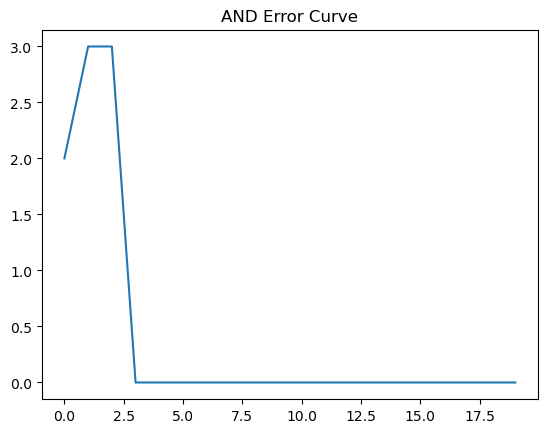

In [3]:
# AND Gate
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

model = Perceptron()
model.fit(X_and,y_and)

print(model.predict(X_and))
print(y_and)

plt.plot(model.errors)
plt.title('AND Error Curve')
plt.show()


[0 1 1 1]
[0 1 1 1]


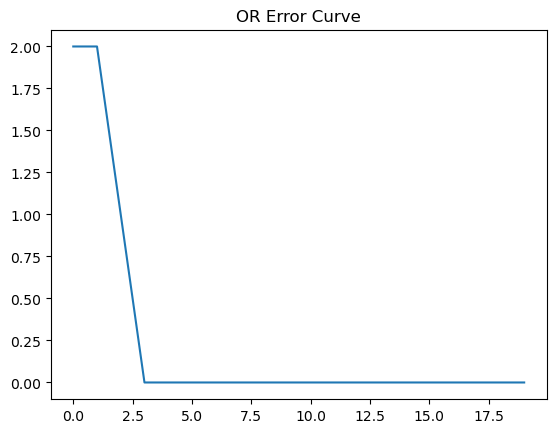

In [4]:
# OR Gate
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])

model = Perceptron()
model.fit(X_or,y_or)

print(model.predict(X_or))
print(y_or)

plt.plot(model.errors)
plt.title('OR Error Curve')
plt.show()


[1 1 0 0]
[0 1 1 0]


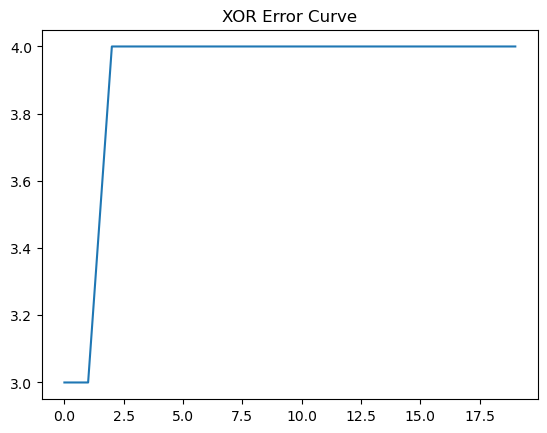

XOR is not linearly separable, therefore a single perceptron cannot learn it.


In [5]:
# XOR Gate
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

model = Perceptron()
model.fit(X_xor,y_xor)

print(model.predict(X_xor))
print(y_xor)

plt.plot(model.errors)
plt.title('XOR Error Curve')
plt.show()

print('XOR is not linearly separable, therefore a single perceptron cannot learn it.')
